In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.logistic_regression import LogisticRegressionGD


df = pd.read_csv("../data/titanic/Titanic_train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df = df[["Pclass", "Sex", "Age","Fare", "Survived"]]
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())
df.head()

,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


In [3]:
df.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
dtype: int64

In [4]:
x = df[["Pclass", "Age", "Sex","Fare"]].values
y = df[["Survived"]].values.ravel()

In [5]:
x = (x - x.mean(axis=0)) / x.std(axis=0)

In [6]:
print(x.shape)
print(y.shape)

(891, 4)
(891,)


In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [8]:
model = LogisticRegressionGD(lr = 0.1, n_iters =5000, lambda_ = 0.1)
model.fit(x_train, y_train)

In [9]:
y_pred = model.predict(x_test)
accuracy = (y_pred == y_test).mean()
print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


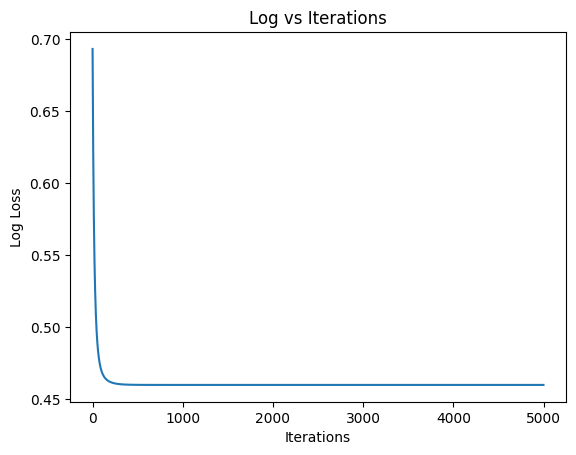

In [10]:
plt.plot(model.losses)
plt.xlabel("Iterations")
plt.ylabel("Log Loss")
plt.title("Log vs Iterations")
plt.show()

In [11]:
x_vis  =df[["Age", "Fare"]].values
y_vis = df[["Survived"]].values.ravel()

x_vis = (x_vis - x_vis.mean(axis = 0)) / x_vis.std(axis = 0)

model.fit(x_vis, y_vis)

#Decision Boundary

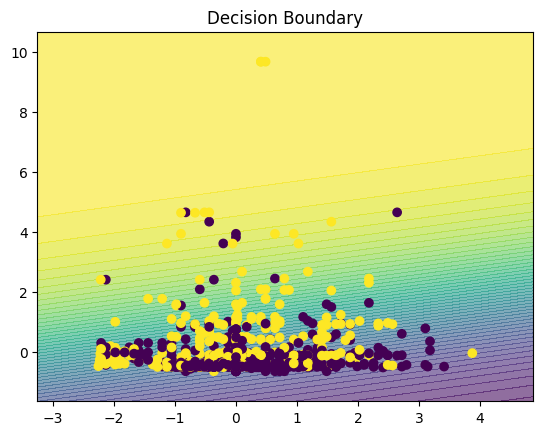

In [12]:
x_min, x_max = x_vis[:, 0].min() - 1, x_vis[:, 0].max() + 1
y_min, y_max = x_vis[:, 1].min() - 1, x_vis[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_prob(grid).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=50, alpha=0.6)
plt.scatter(x_vis[:, 0], x_vis[:, 1], c=y_vis)
plt.title("Decision Boundary")
plt.show()